In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import wandb
from tensorflow.keras.callbacks import ModelCheckpoint
from wandb.integration.keras import WandbCallback
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.metrics import F1Score

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

mean = 0.0550
std = 0.1759

# Parameters
img_size = (70, 155)
batch_size = 32

def preprocess_train(image, label):

    # [0,255] -> [0,1]
    image = tf.cast(image, tf.float32) / 255.0

    # grayscale
    image = tf.image.rgb_to_grayscale(image)

    # augmentation
    image = data_augmentation(image)

    # brightness
    image = tf.image.random_brightness(image, 0.2)

    # inversion
    image = 1.0 - image

    # normalization
    image = (image - mean) / std

    return image, label


def preprocess_test(image, label):

    image = tf.cast(image, tf.float32) / 255.0

    image = tf.image.rgb_to_grayscale(image)

    image = 1.0 - image

    image = (image - mean) / std

    return image, label


# Data augmentation
data_augmentation = tf.keras.Sequential([

    # rotation ~ ±5°
    tf.keras.layers.RandomRotation(
        factor=0.014
    ),

    # translation ±5%
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode='constant'
    ),

    # zoom léger ≈ effet proche du shear
    tf.keras.layers.RandomZoom(
        height_factor=0.05,
        width_factor=0.05
    ),

    # contraste
    tf.keras.layers.RandomContrast(
        factor=0.2
    )

])

In [2]:
# Binary classification

In [3]:
wandb.init(project="cross-out-detection")

callbacks = [
    WandbMetricsLogger(),  
    WandbModelCheckpoint(
        "best_model.keras",   
        monitor="val_loss",
        save_best_only=True,
        mode="min")]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: linneahejsupergroup (linneahejsupergroup-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.


In [9]:
checkpoint = ModelCheckpoint(
    "simple_CNN.h5",          # fichier de sauvegarde
    monitor="val_loss",       # métrique à surveiller
    save_best_only=True,      # 🔥 garde uniquement le meilleur
    mode="min",               # min pour loss, max pour accuracy
    verbose=1)


In [4]:
# -------------------------
# Load datasets
# -------------------------
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/train/images",
    labels="inferred",
    label_mode="binary",
    class_names=["CLEAN", "MIXED"],
    image_size=img_size,
    batch_size=batch_size
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/val/images",
    labels="inferred",
    label_mode="binary",
    class_names=["CLEAN", "MIXED"],
    image_size=img_size,
    batch_size=batch_size
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/test/images",
    labels="inferred",
    label_mode="binary",
    class_names=["CLEAN", "MIXED"],
    image_size=img_size,
    batch_size=batch_size
)

# -------------------------
# Apply preprocessing
# -------------------------
train_dataset = train_dataset.map(
    preprocess_train,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_dataset = val_dataset.map(
    preprocess_test,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_dataset = test_dataset.map(
    preprocess_test,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

W0000 00:00:1778158431.192153   14774 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778158431.303747   14530 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 95994 files belonging to 2 classes.
Found 15118 files belonging to 2 classes.
Found 40612 files belonging to 2 classes.


In [10]:
#CNN

model = models.Sequential([
    # Small details captured
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(70, 155,1)), #1 due to grayscale
    
    # Pooling 
    layers.MaxPooling2D((2,2)),
    
    # More complex details captured
    layers.Conv2D(64, (3,3), activation='relu'),
    
    # Pooling
    layers.MaxPooling2D((2,2)),
    
    # Flatten for dense layer
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    
    # Output (2 classes)
    layers.Dense(1, activation='sigmoid')])

In [11]:
# Compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [12]:
# Training

model.fit(
    train_dataset,
    epochs=100,
    validation_data=val_dataset,
    callbacks=[callbacks, checkpoint])

Epoch 1/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8240 - loss: 0.3642
Epoch 1: val_loss improved from None to 0.35825, saving model to simple_CNN.h5



Epoch 1: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 86s 28ms/step - accuracy: 0.8840 - loss: 0.2402 - val_accuracy: 0.8645 - val_loss: 0.3583
Epoch 2/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9362 - loss: 0.1198
Epoch 2: val_loss improved from 0.35825 to 0.17105, saving model to simple_CNN.h5



Epoch 2: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9357 - loss: 0.1190 - val_accuracy: 0.9171 - val_loss: 0.1710
Epoch 3/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9446 - loss: 0.0958
Epoch 3: val_loss did not improve from 0.17105
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.9432 - loss: 0.0964 - val_accuracy: 0.9096 - val_loss: 0.2074
Epoch 4/100
  74/3000 ━━━━━━━━━━━━━━━━━━━━ 1:36 33ms/step - accuracy: 0.9462 - loss: 0.0776

wandb: WARNING Artifact "run_j3fwql47_model" already exists with the same content. No new version will be created.


3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9358 - loss: 0.1182
Epoch 4: val_loss did not improve from 0.17105
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 96s 32ms/step - accuracy: 0.9399 - loss: 0.1057 - val_accuracy: 0.9137 - val_loss: 0.1841
Epoch 5/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9477 - loss: 0.0851
Epoch 5: val_loss did not improve from 0.17105
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 91s 30ms/step - accuracy: 0.9460 - loss: 0.0882 - val_accuracy: 0.9090 - val_loss: 0.2142
Epoch 6/100
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9483 - loss: 0.0854
Epoch 6: val_loss improved from 0.17105 to 0.16042, saving model to simple_CNN.h5


...


Epoch 27: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 90s 30ms/step - accuracy: 0.9506 - loss: 0.0746 - val_accuracy: 0.9440 - val_loss: 0.0865
Epoch 28/100
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9517 - loss: 0.0749
Epoch 28: val_loss did not improve from 0.08651
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 89s 30ms/step - accuracy: 0.9505 - loss: 0.0751 - val_accuracy: 0.9356 - val_loss: 0.1114
Epoch 29/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9530 - loss: 0.0723
Epoch 29: val_loss did not improve from 0.08651
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 88s 29ms/step - accuracy: 0.9514 - loss: 0.0738 - val_accuracy: 0.9369 - val_loss: 0.1153
Epoch 30/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9517 - loss: 0.0742
Epoch 30: val_loss did not improve from 0.08651
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 91s 30ms/step - accuracy: 0.9507 - loss: 0.0745 - val_accuracy: 0.9434 - val_loss: 0.0879
Epoch 31/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 29


Epoch 36: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 88s 29ms/step - accuracy: 0.9507 - loss: 0.0737 - val_accuracy: 0.9437 - val_loss: 0.0838
Epoch 37/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9491 - loss: 0.0856
Epoch 37: val_loss did not improve from 0.08378
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 88s 29ms/step - accuracy: 0.9490 - loss: 0.0849 - val_accuracy: 0.9393 - val_loss: 0.1101
Epoch 38/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9523 - loss: 0.0720
Epoch 38: val_loss did not improve from 0.08378
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 88s 29ms/step - accuracy: 0.9513 - loss: 0.0722 - val_accuracy: 0.9401 - val_loss: 0.1016
Epoch 39/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9518 - loss: 0.0730
Epoch 39: val_loss did not improve from 0.08378
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 93s 31ms/step - accuracy: 0.9507 - loss: 0.0738 - val_accuracy: 0.9391 - val_loss: 0.1035
Epoch 40/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 30

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9531 - loss: 0.0705
Epoch 78: val_loss did not improve from 0.08378
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 93s 31ms/step - accuracy: 0.9516 - loss: 0.0712 - val_accuracy: 0.9419 - val_loss: 0.0930
Epoch 79/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9526 - loss: 0.0704
Epoch 79: val_loss did not improve from 0.08378
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 89s 30ms/step - accuracy: 0.9515 - loss: 0.0714 - val_accuracy: 0.9410 - val_loss: 0.1018
Epoch 80/100
1692/3000 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.9519 - loss: 0.0701

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [13]:
model = load_model("simple_CNN.h5")

In [14]:
# Evaluation
test_loss, test_acc = model.evaluate(test_dataset)
print("Accuracy :", test_acc)

1270/1270 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9471 - loss: 0.0802
Accuracy : 0.9471338391304016


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


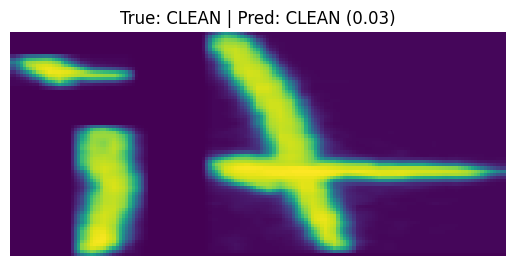

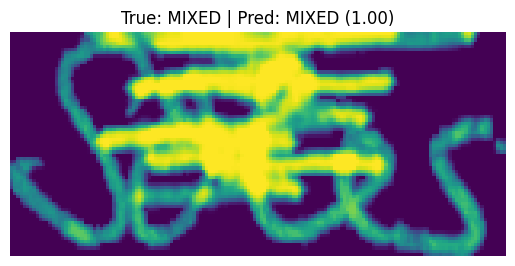

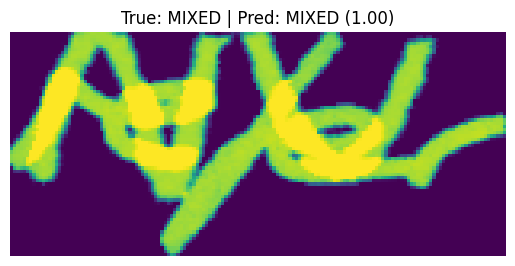

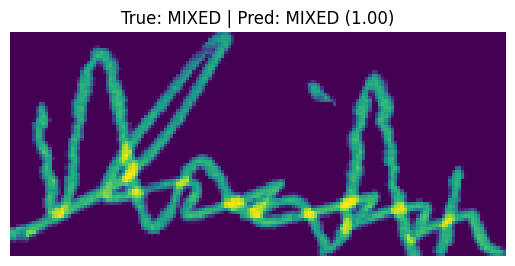

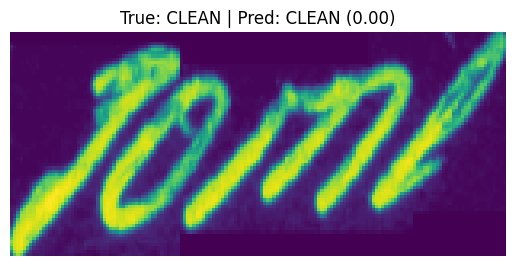

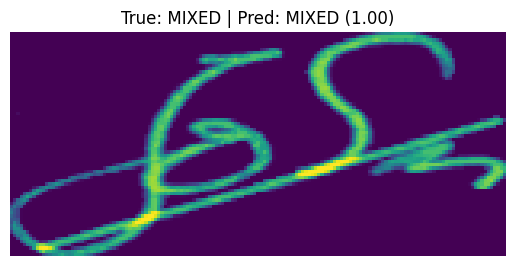

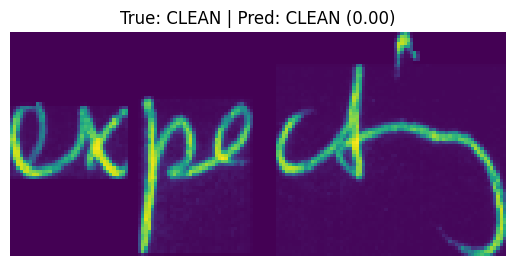

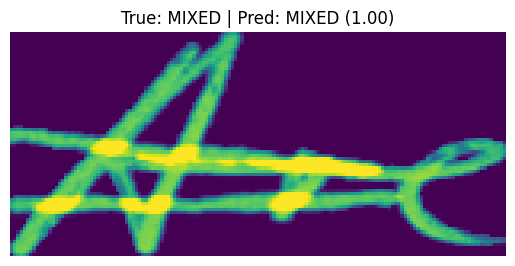

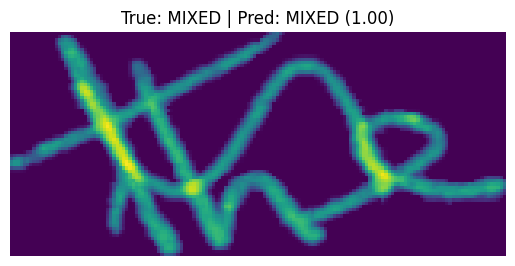

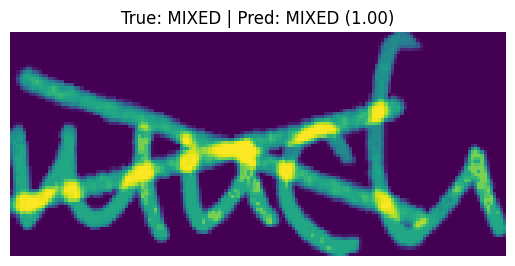

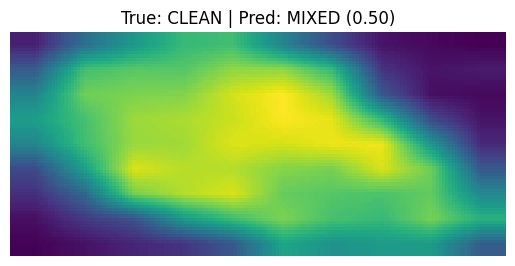

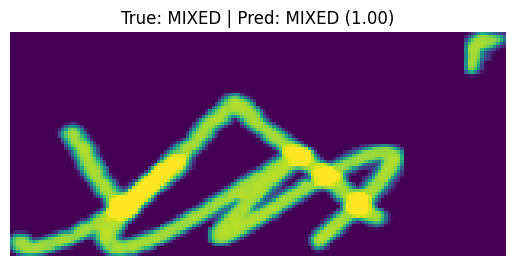

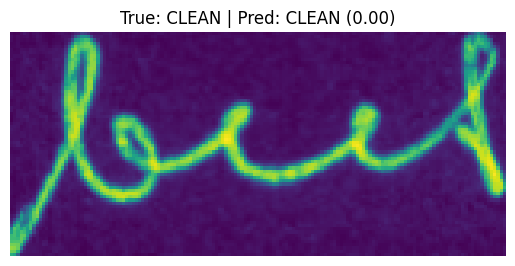

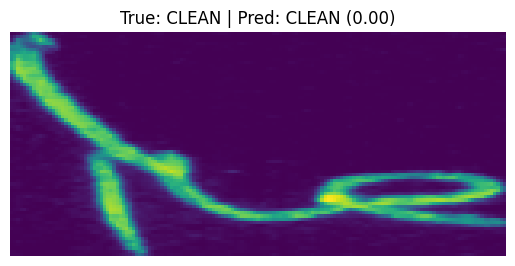

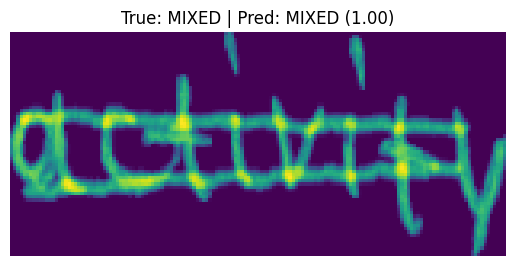

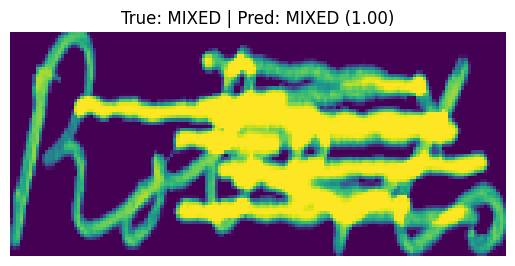

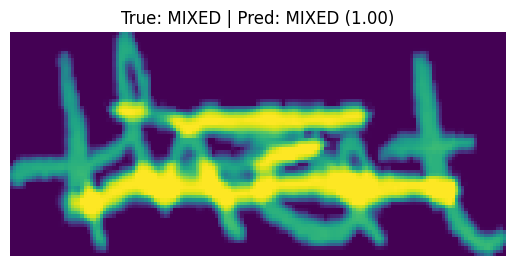

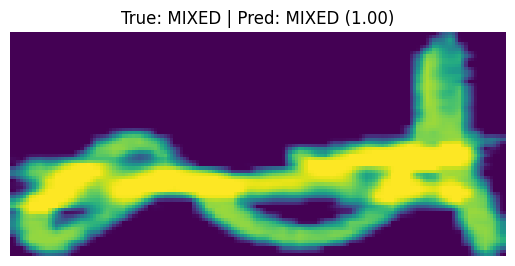

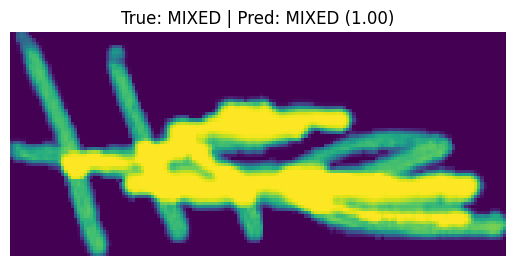

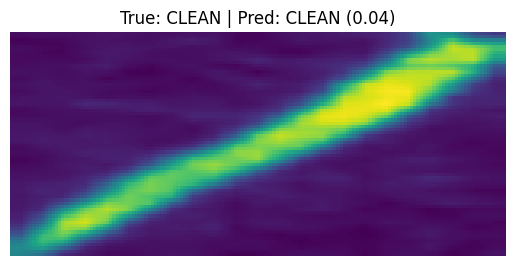

In [15]:
class_names = ["CLEAN", "MIXED"]  # adapte si besoin

for images, labels in test_dataset.take(1):
    preds = model.predict(images)

    for i in range(20):
        plt.imshow(images[i].numpy())
        
        true_label = int(labels[i].numpy()[0])
        pred_label = int(preds[i][0] > 0.5)

        plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]} ({preds[i][0]:.2f})")
        plt.axis("off")
        plt.show()

In [17]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
print(np.unique(y_true, return_counts=True))

(array([0., 1.], dtype=float32), array([47997, 47997]))


In [18]:
print("y_pred:", np.unique(y_pred, return_counts=True))

y_pred: (array([0, 1]), array([52305, 43689]))


In [11]:
wandb.finish()

epoch/accuracy,▁▆▆▆▇▇▇████████████████████▇█▇▇▇█▇▇▇▇▇▇▇
epoch/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▁▂▂▂▂▂▂
epoch/val_accuracy,▁▃▄▆▆▇█▇▇█▇▇▆▆▇▇█▆▇█▇▇▆▇▇▆▆▆▇▇▇▅▆▆▆▄▆▆▅▆
epoch/val_loss,▅▅▃▃▂▂▁▂▁▄▃▃▂▂▂▃▃▃▃▃▃▂▃▃▃▃▅▂▃▅▃▅▇▅▄▅▄█▇▄
epoch/accuracy,0.87174
epoch/epoch,99
epoch/learning_rate,0.001
epoch/loss,0.34455
epoch/val_accuracy,0.84614


In [20]:
# Multi-class classification

In [12]:
wandb.init(project="cross-out-detection")

callbacks = [
    WandbMetricsLogger(),  
    WandbModelCheckpoint(
        "best_model.keras",   
        monitor="val_loss",
        save_best_only=True,
        mode="min")]

In [13]:
checkpoint = ModelCheckpoint(
    "multiclass_CNN.h5",          # fichier de sauvegarde
    monitor="val_loss",       # métrique à surveiller
    save_best_only=True,      # 🔥 garde uniquement le meilleur
    mode="min",               # min pour loss, max pour accuracy
    verbose=1)


In [14]:
# Charge the dataset
# Parameters
img_size = (70, 155)
batch_size = 32

#load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/train/images",
    labels="inferred",
    label_mode="int",
    class_names=["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"],  
    image_size=img_size,
    batch_size=32
)

# Load validation data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/val/images",
    labels="inferred",
    label_mode="int",
    class_names=["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"],  
    image_size=img_size,
    batch_size=32
)
#Load test data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/test/images",
    labels="inferred",
    label_mode="int",
    class_names=["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"],  
    image_size=img_size,
    batch_size=32
)

# -------------------------
# Apply preprocessing
# -------------------------
train_dataset = train_dataset.map(
    preprocess_train,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_dataset = val_dataset.map(
    preprocess_test,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_dataset = test_dataset.map(
    preprocess_test,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

Found 383977 files belonging to 8 classes.
Found 60472 files belonging to 8 classes.
Found 162448 files belonging to 8 classes.


In [15]:
#CNN

model = models.Sequential([
    # Small details captured
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(70, 155,1)),
    
    # Pooling 
    layers.MaxPooling2D((2,2)),
    
    # More complex details captured
    layers.Conv2D(64, (3,3), activation='relu'),
    
    # Pooling
    layers.MaxPooling2D((2,2)),
    
    # More complex details captured
    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Conv2D(256, (3,3), activation='relu'),

    
    # Pooling
    layers.MaxPooling2D((2,2)),
    
    # Flatten for dense layer
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    
    # Output (8 classes)
    layers.Dense(8, activation='softmax')])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Training
model.fit(train_dataset, epochs=100, validation_data=val_dataset, callbacks = [checkpoint,WandbMetricsLogger()])

Epoch 1/100
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7102 - loss: 0.7456
Epoch 1: val_loss improved from None to 0.42581, saving model to multiclass_CNN.h5



Epoch 1: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 689s 57ms/step - accuracy: 0.7849 - loss: 0.5524 - val_accuracy: 0.8321 - val_loss: 0.4258
Epoch 2/100
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8386 - loss: 0.4109
Epoch 2: val_loss improved from 0.42581 to 0.38371, saving model to multiclass_CNN.h5



Epoch 2: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 694s 58ms/step - accuracy: 0.8428 - loss: 0.4010 - val_accuracy: 0.8470 - val_loss: 0.3837
Epoch 3/100
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8517 - loss: 0.3775
Epoch 3: val_loss improved from 0.38371 to 0.36096, saving model to multiclass_CNN.h5



Epoch 3: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 705s 59ms/step - accuracy: 0.8542 - loss: 0.3716 - val_accuracy: 0.8587 - val_loss: 0.3610
Epoch 4/100
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8594 - loss: 0.3561
Epoch 4: val_loss improved from 0.36096 to 0.36049, saving model to multiclass_CNN.h5



Epoch 4: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 709s 59ms/step - accuracy: 0.8605 - loss: 0.3537 - val_accuracy: 0.8581 - val_loss: 0.3605
Epoch 5/100
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8641 - loss: 0.3448
Epoch 5: val_loss improved from 0.36049 to 0.35120, saving model to multiclass_CNN.h5



Epoch 5: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 708s 59ms/step - accuracy: 0.8653 - loss: 0.3424 - val_accuracy: 0.8602 - val_loss: 0.3512
Epoch 6/100
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8683 - loss: 0.3353
Epoch 6: val_loss did not improve from 0.35120
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 683s 57ms/step - accuracy: 0.8689 - loss: 0.3337 - val_accuracy: 0.8607 - val_loss: 0.3534
Epoch 7/100
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8711 - loss: 0.3285
Epoch 7: val_loss improved from 0.35120 to 0.34769, saving model to multiclass_CNN.h5



Epoch 7: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 681s 57ms/step - accuracy: 0.8713 - loss: 0.3277 - val_accuracy: 0.8624 - val_loss: 0.3477
Epoch 8/100
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8730 - loss: 0.3227
Epoch 8: val_loss improved from 0.34769 to 0.34031, saving model to multiclass_CNN.h5



Epoch 8: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 686s 57ms/step - accuracy: 0.8731 - loss: 0.3227 - val_accuracy: 0.8672 - val_loss: 0.3403
Epoch 9/100
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8746 - loss: 0.3188
Epoch 9: val_loss improved from 0.34031 to 0.33832, saving model to multiclass_CNN.h5



Epoch 9: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 684s 57ms/step - accuracy: 0.8744 - loss: 0.3197 - val_accuracy: 0.8663 - val_loss: 0.3383
Epoch 10/100
  426/12000 ━━━━━━━━━━━━━━━━━━━━ 10:23 54ms/step - accuracy: 0.8720 - loss: 0.3206

In [ ]:
model = load_model("multiclass_CNN.h5")

In [ ]:
# Evaluation
test_loss, test_acc = model.evaluate(test_dataset)
print("Accuracy :", test_acc)

In [ ]:
# récupère automatiquement les noms des classes
class_names = ["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"]

for images, labels in test_dataset.take(1):
    preds = model.predict(images)

    for i in range(6):
        plt.imshow(images[i].numpy())  

        # labels vrais
        true_label = int(labels[i].numpy())

        # prédiction
        pred_label = np.argmax(preds[i])

        plt.title(
            f"True: {class_names[true_label]} | "
            f"Pred: {class_names[pred_label]} ({np.max(preds[i]):.2f})"
        )
        plt.axis("off")
        plt.show()

In [ ]:
wandb.finish()